>## Assignment: The irreducible mass of black holes.

Consider a rotating black hole. In [1969](https://ui.adsabs.harvard.edu/abs/1969NCimR...1..252P/abstract), Roger Penrose (now [Nobel Prize in Physics](https://www.nobelprize.org/prizes/physics/2020/penrose/facts/) for the theory of black holes) discovered that one can extract energy from a rotating black hole:

![](https://inspirehep.net/files/268d28446b405e134199d84f67c23792)

(figure from [Harada, Kimura 2014](https://ui.adsabs.harvard.edu/abs/2014CQGra..31x3001H/abstract)).

A rotating black-hole has a region called ergosphere such that in falling particles have negative energy. Penrose imagined a particle that enters that region and decays: half will fall in and half will escape to infinity, carrying some energy with it. In a nutshell, we've extracted energy=mass from a black hole! It turns out that one also has to extract angular momentum, not just energy (and here you'll need some GR do to this calculation, see e.g. the famous textbook by [Misner, Thorne and Weeler](https://press.princeton.edu/books/hardcover/9780691177793/gravitation)). But angular momentum runs our first, such that a repeated series of Penrose processes leaves behind a non-rotating BH with a remnant mass which is called "irreducible". This is a famous result by [Christodoulou 1970](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.25.1596) and is closely related to the even more famous area law by [Hawking (1971)](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.26.1344) (which in turn is the foundation of black-hole thermodynamics).


For a BH of mass $M$, and spin $\chi\in [0,1]$, the irreducible mass is 
$$
M_{\rm irr} = %\sqrt{\frac{M^2+\sqrt{M^4-S^2}}{2}} = 
 M \sqrt{\frac{1+\sqrt{1-\chi^2}}{2}}
%\label{mirrdef}
$$
For convenience, let us define $f= M_{\rm irr}/M$

Suppose you have repeated measurements of $M$ and $\chi$. This is just because we're still frequentists for now. When we will put our Bayesian hat on, these distributions will be the *posterior samples* from a single measurement.

Let's assume that

- the spin $\chi$ is uniformly distributed between 0 and 1.
- the mass $M$ is normally distributed with mean $\mu$ and standard deviation $\sigma$.

These are simplistic assumption that, however, are not too far from what can be measured with gravitational-wave detectors. It's a toy model, but not a totally unreasonable one.

**Tasks**:

1. Start with a value of $\sigma=0.02$. Note that $\mu$ is a scale and not a parameter: you can normalize all quantities with a dimension of mass by $\mu$. Just set $\mu=1$ in your code and remember that all masses in the problem are measured in units of $\mu$. 

2. Plot the resulting pdf of $M_{\rm irr}$. First try a histogram with the rules of thumb we've seen above.

*Hint*: You don't know the functional form of the pdf of $M_{\rm irr}$... but you don't need it if you just want to generate samples! That's the nice thing about numerics!

3. Using the same samples, plot the distribution of $M_{\rm irr}$ using a KDE.

4. Compute the KS distance between ${M_{\rm irr}}$ and ${f}$ as a function of $\sigma$. Discuss the limits at large and small values of $\sigma$. 

5. Compute the KS distance between ${M_{\rm irr}}$ and $M$ as a function of $\sigma$. Discuss the limits at large and small values of $\sigma$.

6. You should find that (i) $M_{\rm irr}$ is distributed like $f$ if ${\sigma}\ll \mu$ and (ii) $M_{\rm irr}$ is distributed like $M$ if $\sigma\gg \mu$.


7. (At home...) Compute the pdfs of $M_{\rm irr}$ from their mathematical definitions, plot them, and check if they agree with your KDE.

*Hint 1*: First compute the pdf of $f$, that is just a change of variable. We saw how to do this in a previous lecture. The answer is:
\begin{equation}
\pi(f) = 2\frac{2 f^2-1}{\sqrt{1 - f^2}}\,.
\end{equation}

*Hint 2*: Then compute the pdf of $M_{\rm irr}$, you want to use [this theorem](https://en.wikipedia.org/wiki/Distribution_of_the_product_of_two_random_variables) for the product of two random variables. The answer is only semi-analytic (unless you know how to solve that integral? If so please tell me!)
\begin{equation}
p(M_{\rm irr})  = \frac{\sqrt{2/\pi}}{\sigma} \int_{1/\sqrt{2}}^1 \exp\left[{-\frac{(M_{\rm irr}/f -\mu)^2}{2\sigma^2}}\right]  \frac{2 f^2-1}{f \sqrt{1 - f^2}}  \,\, {\rm d}f\,. 
\end{equation}


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm, gaussian_kde, ks_2samp
from scipy.integrate import quad
from astropy.visualization.hist import hist as fancyhist

In [33]:
rng = np.random.default_rng(42) # random seed kept the same for reproducibility

def sample_M(mu, sigma, size, rng=rng):
    """
    Sampling M ~ Normal(mu, sigma) truncated to M>0 (physical).
    Returns a sample for M, given mu, sigma and number of samples=size.
    """
    a = (0 - mu) / sigma  # lower bound in standard normal units
    b = np.inf
    return truncnorm.rvs(a, b, loc=mu, scale=sigma, size=size, random_state=rng)

def chi_to_f(chi):
    """
    Converting chi values to f values using
    f = Mirr/M = sqrt((1 + sqrt(1-chi^2))/2), with chi in [0,1].
    f in [1/sqrt(2), 1].
    Returns f given the chi.
    """
    return np.sqrt((1 + np.sqrt(1 - chi**2)) / 2)

def sample_f(size, rng=rng):
    """ 
    Sample chi ~ Uniform [0,1] and convert to f = Mirr/M; 
    effectively sampling f without knowing its distribution.
    Returns a sample of f with a given size.
    """
    chi = rng.uniform(0.0, 1.0, size=size) # uniform in [0,1]
    return chi_to_f(chi)

def sample_Mirr(mu, sigma, size, rng=rng):
    """ 
    Sampling M_irr values by sampling 
    M ~ Normal(mu, sigma)  and 
    f (which is obtained from chi ~ Uniform [0,1]).
    Returns M, f, Mirr given the mu, sigma and number of samples.
    """
    M = sample_M(mu, sigma, size, rng=rng)
    f = sample_f(size, rng=rng)
    Mirr = M * f
    return M, f, Mirr


Using the above functions, we can obtain fake sample data for the mass and spin of black holes, and their irreducible masses.

We then create a histogram of the $M_{\rm irr}$ samples.

Below are two rules of thumb commonly used for choosing the histogram bin widths given a data. They try to minimize the integrated error between the PDF and the histogram, one using positional statistics (quartiles) and the other using the standard deviation.
- [Freedman-Diaconis Rule](https://en.wikipedia.org/wiki/Freedman%E2%80%93Diaconis_rule): uses $h=2\,\mathrm{IQR}\,n^{-1/3}$, so it is more robust to outliers/heavy tails.
- [Scott's Rule](https://en.wikipedia.org/wiki/Scott%27s_rule): uses $h=3.5\,\sigma\,n^{-1/3}$, optimal for near-Gaussian data but more sensitive to outliers.

In both cases, the number of bins is then derived from the chosen width via $k=\left\lceil\frac{x_{\max}-x_{\min}}{h}\right\rceil$.

In [42]:
def freedman_diaconis_bin_width(x):
    q25, q75 = np.percentile(x, [25, 75])
    iqr = q75 - q25
    n = len(x)
    return 2 * iqr / (n ** (1/3))

def scott_bin_width(x):
    sigma = np.std(x, ddof=1)
    n = len(x)
    return 3.5 * sigma / (n ** (1/3))

def histogram_bins_from_width(x, width):
    # Guard against pathological width
    width = max(width, 1e-6)
    n_bins = int(np.ceil((x.max() - x.min()) / width))
    return max(n_bins, 10)

FD bin width: 0.002758156332801299  -> bins: 144
Scott bin width: 0.0038569575777815833  -> bins: 103


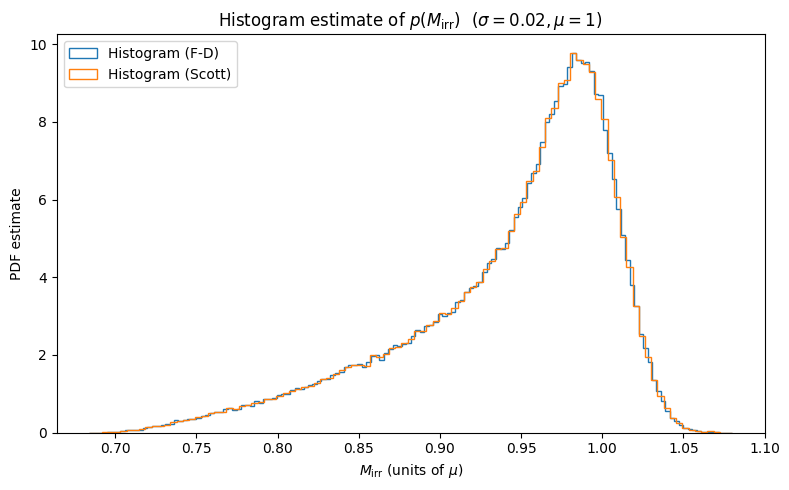

In [45]:
mu = 1.0
sigma = 0.02
N = 200000  # large enough for smooth plots; reduce if slow

M, f, Mirr = sample_Mirr(mu, sigma, N)

# Choose a binning rule (try both!)
w_fd = freedman_diaconis_bin_width(Mirr)
bins_fd = histogram_bins_from_width(Mirr, w_fd)

w_scott = scott_bin_width(Mirr)
bins_scott = histogram_bins_from_width(Mirr, w_scott)

print("FD bin width:", w_fd, " -> bins:", bins_fd)
print("Scott bin width:", w_scott, " -> bins:", bins_scott)

plt.figure(figsize=(8,5))

plt.hist(Mirr, bins=bins_fd, density=True, histtype='step', label="Histogram (F-D)")
plt.hist(Mirr, bins=bins_scott, density=True, histtype='step', label="Histogram (Scott)")
# density = True normalizes the histogram by the total area under the histogram, 
# so that it resembles a PDF instead of raw number counts on the Y-axis.

plt.xlabel(r"$M_{\rm irr}$ (units of $\mu$)")
plt.ylabel("PDF estimate")
plt.title(r"Histogram estimate of $p(M_{\rm irr})$  ($\sigma=0.02, \mu=1$)")
plt.legend()
plt.tight_layout()
plt.show()

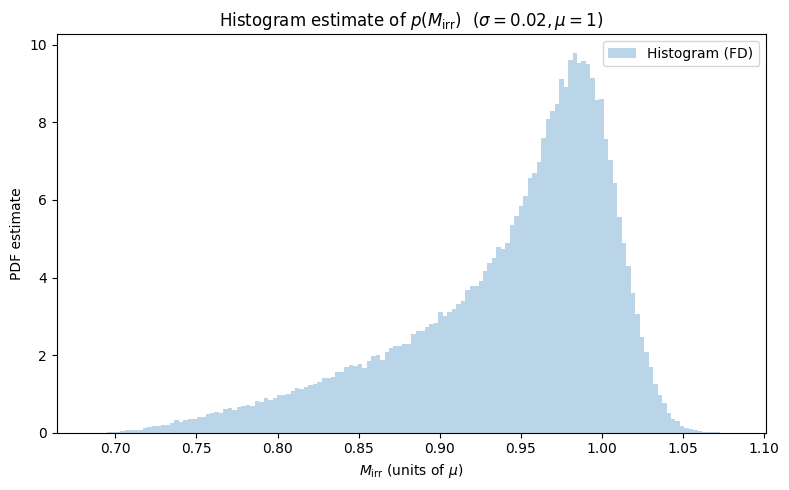

In [ ]:
# We can also do this with hist from astropy, (imported as fancyhist here, to avoid clashes with plt.hist).
# It directly computes the bins, we don't need to do anything then!

plt.figure(figsize=(8,5))
fancyhist(Mirr, bins="freedman", histtype="stepfilled", density=True, alpha=0.3, label="Histogram (FD)")
plt.xlabel(r"$M_{\rm irr}$ (units of $\mu$)")
plt.ylabel("PDF estimate")
plt.title(r"Histogram estimate of $p(M_{\rm irr})$  ($\sigma=0.02, \mu=1$)")
plt.legend()
plt.tight_layout()
plt.show()

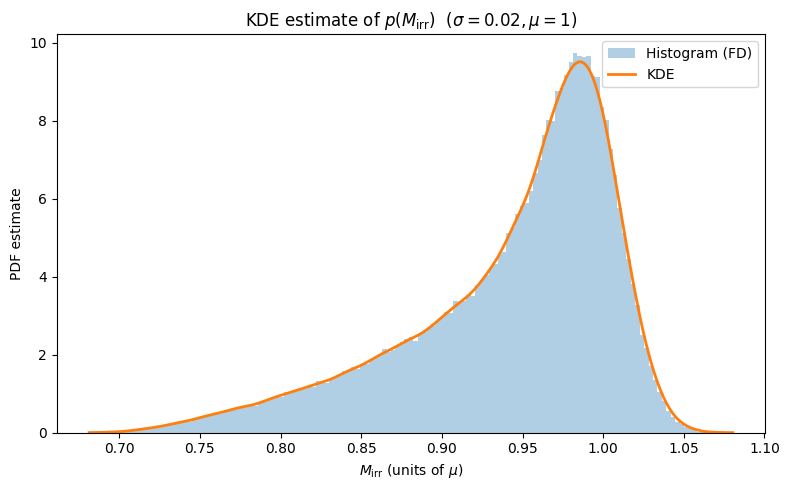

In [26]:
kde = gaussian_kde(Mirr)  # default bandwidth is Scott's rule

x_grid = np.linspace(np.min(Mirr), np.max(Mirr), 1500)
pdf_kde = kde(x_grid)

plt.figure(figsize=(8,5))
plt.hist(Mirr, bins=bins_fd, density=True, alpha=0.35, label="Histogram (FD)")
plt.plot(x_grid, pdf_kde, linewidth=2, label="KDE")
plt.xlabel(r"$M_{\rm irr}$ (units of $\mu$)")
plt.ylabel("PDF estimate")
plt.title(r"KDE estimate of $p(M_{\rm irr})$  ($\sigma=0.02, \mu=1$)")
plt.legend()
plt.tight_layout()
plt.show()

If $\sigma\ll 1$, then $M \approx 1$ and $f = M_{\rm irr}/M \approx M_{\rm irr}$. 

However, if $\sigma$ is not small, then the values of $M$ are spread more, and the distribution of $f$ and $M_{\rm irr}$ are not going to be similar.

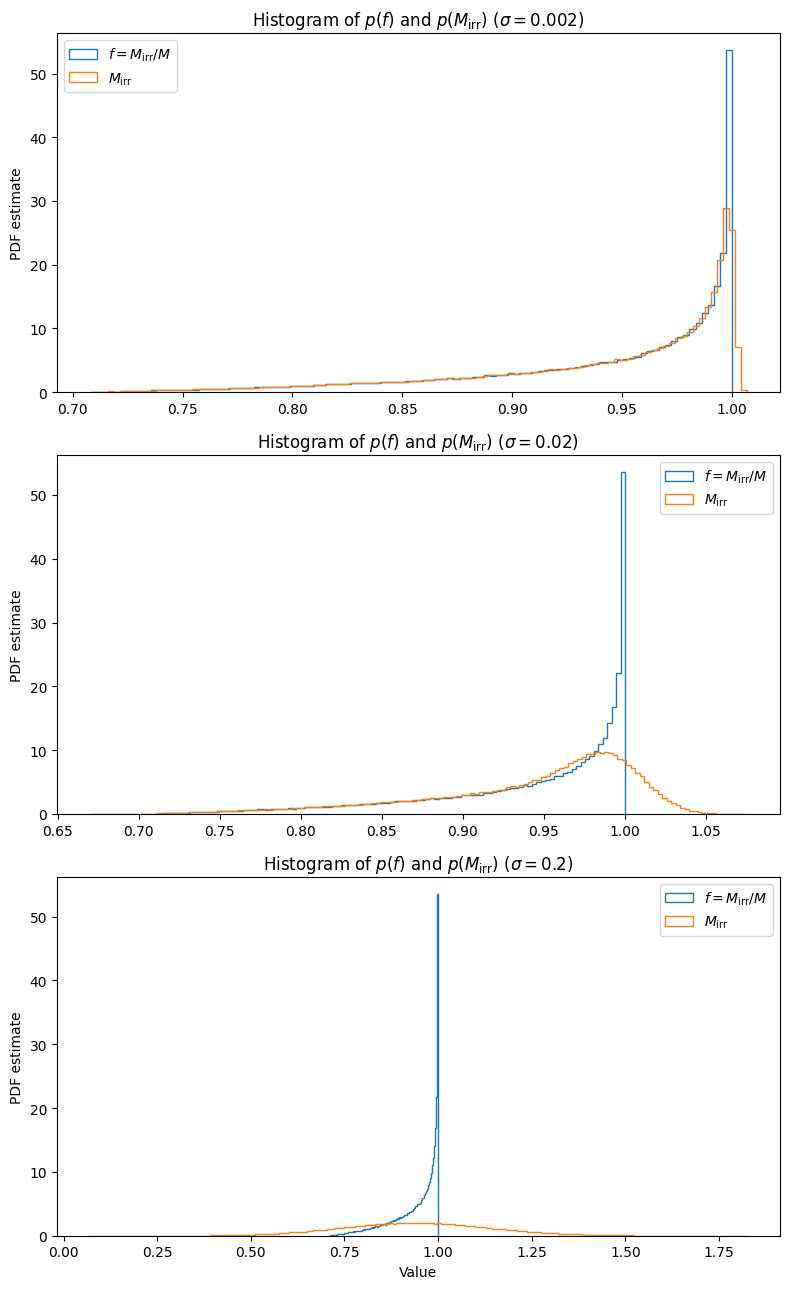

In [ ]:
# Histograms of f and M_irr for different sigma values
sigmas = [0.002, 0.02, 0.2]
N = N  

fig, axes = plt.subplots(3, 1, figsize=(8, 13))

for ax, s in zip(axes, sigmas):
    M_s, f_s, Mirr_s = sample_Mirr(mu, s, N, rng=rng)

    w_fd_f = freedman_diaconis_bin_width(f_s)
    bins_fd_f = histogram_bins_from_width(f_s, w_fd_f)

    w_fd_mirr = freedman_diaconis_bin_width(Mirr_s)
    bins_fd_mirr = histogram_bins_from_width(Mirr_s, w_fd_mirr)

    ax.hist(f_s, bins=bins_fd_f, density=True, histtype='step', label=r"$f = M_{\rm irr}/M$")
    ax.hist(Mirr_s, bins=bins_fd_mirr, density=True, histtype='step', label=r"$M_{\rm irr}$")
    ax.set_ylabel("PDF estimate")
    ax.set_title(rf"Histogram of $p(f)$ and $p(M_{{\rm irr}})$ ($\sigma={s}$)")
    ax.legend()

axes[-1].set_xlabel("Value")
plt.tight_layout()
plt.show()

Now we compare the difference in these distributions as a function of $\sigma$, using the Kolmogorov-Smirnov test.

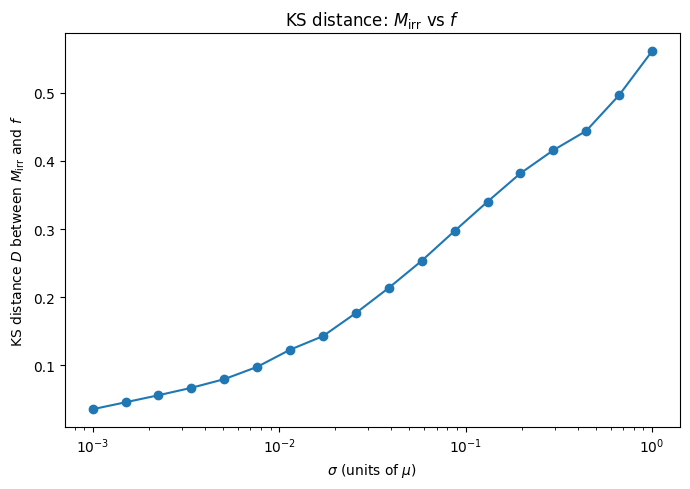

In [27]:
mu = 1.0
N = 10000  # KS curves don't need 200k; keep runtime reasonable

sigmas = np.logspace(-3, 0, 18)  # from 1e-3 to 1 (in units of mu)
D_Mirr_f = []

for s in sigmas:
    M, f, Mirr = sample_Mirr(mu, s, N)
    D = ks_2samp(Mirr, f).statistic
    D_Mirr_f.append(D)

D_Mirr_f = np.array(D_Mirr_f)

plt.figure(figsize=(7,5))
plt.plot(sigmas, D_Mirr_f, marker='o')
plt.xscale("log")
plt.xlabel(r"$\sigma$ (units of $\mu$)")
plt.ylabel(r"KS distance $D$ between $M_{\rm irr}$ and $f$")
plt.title(r"KS distance: $M_{\rm irr}$ vs $f$")
plt.tight_layout()
plt.show()

If we now look at the distribution for the irreducible mass,

$M_{\rm irr} = M \times f$,

with $M$ and $f$ coming from their own distributions,

then $M_{\rm irr}$ follows the distribution that will be obtained by the product of random variables $M$ and $f$. 

(Note that the distribution for $f$ is constant, and doesn't depend on any parameters)

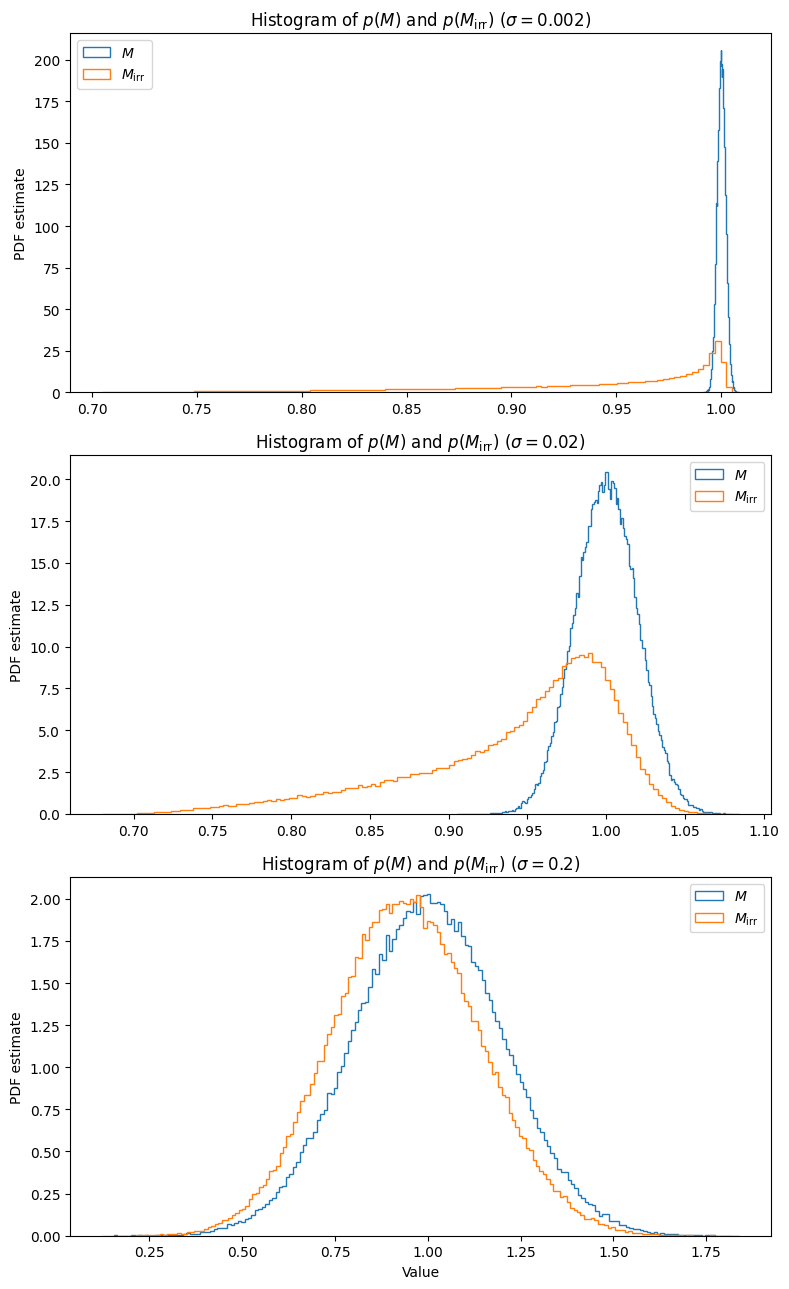

In [64]:
# Histograms of M and M_irr for different sigma values
sigmas = [0.002, 0.02, 0.2]
N = N  

fig, axes = plt.subplots(3, 1, figsize=(8, 13))

for ax, s in zip(axes, sigmas):
    M_s, f_s, Mirr_s = sample_Mirr(mu, s, N, rng=rng)

    w_fd_M = freedman_diaconis_bin_width(M_s)
    bins_fd_M = histogram_bins_from_width(M_s, w_fd_M)

    w_fd_mirr = freedman_diaconis_bin_width(Mirr_s)
    bins_fd_mirr = histogram_bins_from_width(Mirr_s, w_fd_mirr)

    ax.hist(M_s, bins=bins_fd_M, density=True, histtype='step', label=r"$M$")
    ax.hist(Mirr_s, bins=bins_fd_mirr, density=True, histtype='step', label=r"$M_{\rm irr}$")
    ax.set_ylabel("PDF estimate")
    ax.set_title(rf"Histogram of $p(M)$ and $p(M_{{\rm irr}})$ ($\sigma={s}$)")
    ax.legend()

axes[-1].set_xlabel("Value")
plt.tight_layout()
plt.show()

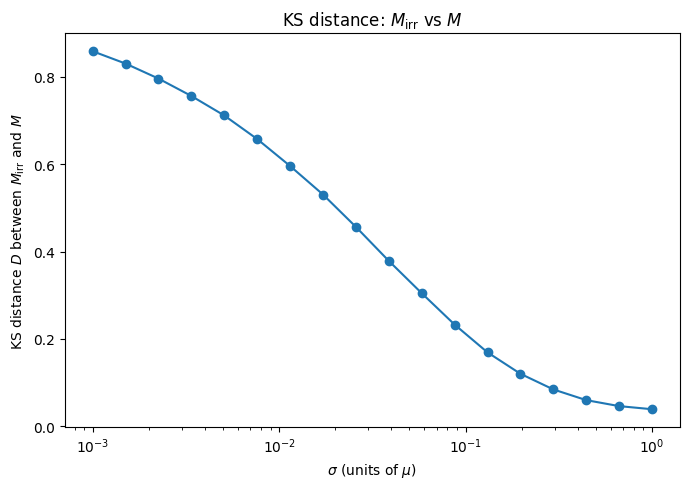

In [59]:
D_Mirr_M = []

for s in sigmas:
    M, f, Mirr = sample_Mirr(mu, s, N)
    D = ks_2samp(Mirr, M).statistic
    D_Mirr_M.append(D)

D_Mirr_M = np.array(D_Mirr_M)

plt.figure(figsize=(7,5))
plt.plot(sigmas, D_Mirr_M, marker='o')
plt.xscale("log")
plt.xlabel(r"$\sigma$ (units of $\mu$)")
plt.ylabel(r"KS distance $D$ between $M_{\rm irr}$ and $M$")
plt.title(r"KS distance: $M_{\rm irr}$ vs $M$")
plt.tight_layout()
plt.show()


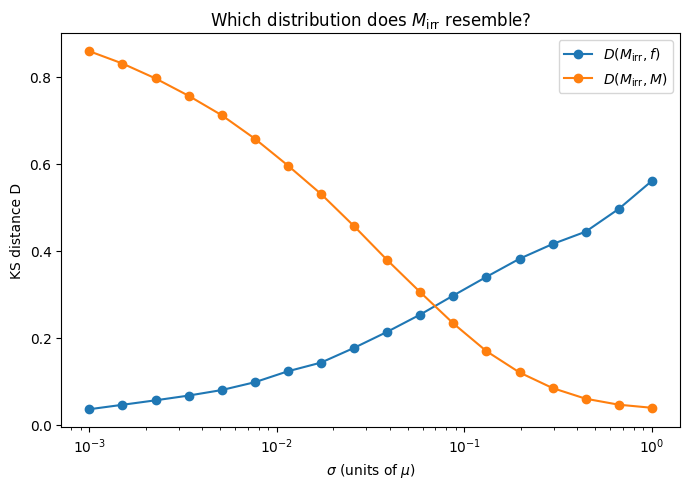

In [60]:
plt.figure(figsize=(7,5))
plt.plot(sigmas, D_Mirr_f, marker='o', label=r"$D(M_{\rm irr}, f)$")
plt.plot(sigmas, D_Mirr_M, marker='o', label=r"$D(M_{\rm irr}, M)$")
plt.xscale("log")
plt.xlabel(r"$\sigma$ (units of $\mu$)")
plt.ylabel("KS distance D")
plt.title("Which distribution does $M_{\\rm irr}$ resemble?")
plt.legend()
plt.tight_layout()
plt.show()

### What should we expect?

The behavior of the KS distances as a function of $\sigma$ can be understood
from simple limiting arguments.

---

#### Small-$\sigma$ limit ($\sigma \ll \mu$)

When the uncertainty on the mass is very small,
the measured mass is nearly constant:

$$
M \approx \mu.
$$

In this limit,
the irreducible mass becomes

$$
M_{\rm irr} = M f \approx \mu f.
$$

Since we have set $\mu = 1$ in our code,
this implies

$$
M_{\rm irr} \approx f.
$$

Therefore:
- the distribution of $M_{\rm irr}$ should closely resemble the distribution of $f$,
- the KS distance between $M_{\rm irr}$ and $f$ should be small,
- the KS distance between $M_{\rm irr}$ and $M$ should be large,
  since $M$ is nearly a delta function while $f$ varies significantly.

---

#### Large-$\sigma$ limit ($\sigma \gg \mu$)

When the uncertainty on the mass is very large,
the distribution of $M$ is broad.

In this regime, multiplying $M$ by the factor $f \in [1/\sqrt{2}, 1]$
rescales each realization by an order-unity amount,
but does not significantly change the overall shape of the distribution.

As a result:
- the distribution of $M_{\rm irr}$ becomes similar to that of $M$,
- the KS distance between $M_{\rm irr}$ and $M$ decreases,
- the KS distance between $M_{\rm irr}$ and $f$ increases,
  since $f$ alone no longer captures the dominant source of variation.

---

#### Interpretation

These limits illustrate a general principle:

> The observable that dominates the uncertainty determines the shape of the distribution.

In the small-$\sigma$ regime, the spin-dependent factor $f$ controls the distribution.
In the large-$\sigma$ regime, the mass uncertainty dominates instead.

This behavior will later be reinterpreted in a Bayesian framework,
where these samples correspond to posterior distributions rather than repeated measurements.


___

#### Analytical result 


We define

$$
f(\chi) \equiv \frac{M_{\rm irr}}{M} = \sqrt{\frac{1 + \sqrt{1-\chi^2}}{2}},
\qquad \chi \in [0,1].
$$

This mapping is monotonic, and it implies the range

$$
f \in \left[\frac{1}{\sqrt{2}},\, 1\right].
$$

Since $\chi$ is uniformly distributed on $[0,1]$, we have $\pi_\chi(\chi)=1$ on $[0,1]$.
Using the change-of-variables formula,

$$
\pi_f(f) = \pi_\chi(\chi(f))\left|\frac{d\chi}{df}\right|,
$$

one finds the closed-form result:

$$
\pi(f) = 2\frac{2 f^2-1}{\sqrt{1 - f^2}},
\qquad f\in\left[\frac{1}{\sqrt{2}},1\right].
$$

(Outside this interval, $\pi(f)=0$.)


Integral of pi(f) over [1/sqrt(2), 1] = 0.999999999997427 +/- 5.600653274484557e-11


/var/folders/rb/fzfc6c755m97072_t90425cw0000gn/T/ipykernel_19046/2620996482.py:6: RuntimeWarning: divide by zero encountered in divide
  out[mask] = 2.0 * (2*f[mask]**2 - 1.0) / np.sqrt(1.0 - f[mask]**2)


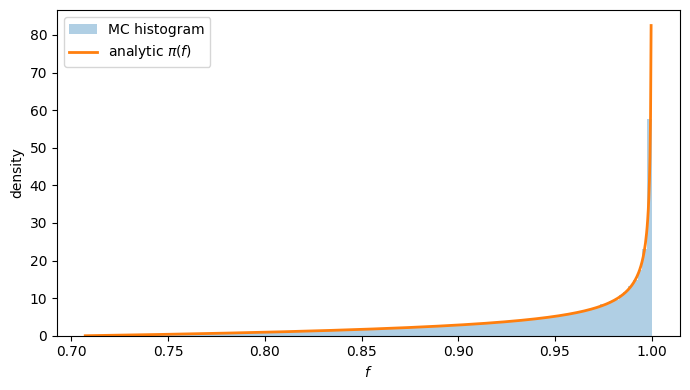

In [61]:
def pi_f(f): # probability density function of f
    f = np.asarray(f)
    out = np.zeros_like(f, dtype=float)
    lo, hi = 1/np.sqrt(2), 1.0
    mask = (f >= lo) & (f <= hi)
    out[mask] = 2.0 * (2*f[mask]**2 - 1.0) / np.sqrt(1.0 - f[mask]**2)
    return out

# Check normalization
lo, hi = 1/np.sqrt(2), 1.0 # limits of f
norm, err = quad(lambda x: pi_f(x), lo, hi) # integrate pi(f) over [1/sqrt(2), 1]
print("Integral of pi(f) over [1/sqrt(2), 1] =", norm, "+/-", err) # should be 1

# Compare to sampled f
rng = np.random.default_rng(0) # reproducible
chi = rng.uniform(0, 1, 200_000) # uniform in [0,1]
f_samp = np.sqrt((1 + np.sqrt(1 - chi**2))/2) # compute f from chi

f_grid = np.linspace(lo, hi, 1000) # grid for plotting

plt.figure(figsize=(7,4))
plt.hist(f_samp, bins=120, density=True, alpha=0.35, label="MC histogram")
plt.plot(f_grid, pi_f(f_grid), lw=2, label=r"analytic $\pi(f)$")
plt.xlabel(r"$f$")
plt.ylabel("density")
plt.legend()
plt.tight_layout()
plt.show()

#### Analytic PDF of $M_{\rm irr} = M f$

Let $Z = M_{\rm irr} = M f$, where $M$ and $f$ are independent.

The distribution of a product of independent random variables gives:

$$
p_Z(z) = \int p_M\!\left(\frac{z}{f}\right)\,\pi_f(f)\,\frac{1}{|f|}\,df.
$$

(Exercise: Prove this formula)

Since $f>0$ on its support, $|f|=f$ and the integral runs over

$$
f\in\left[\frac{1}{\sqrt{2}}, 1\right].
$$

With

$$
p_M(m) = \frac{1}{\sqrt{2\pi}\sigma}\exp\!\left[-\frac{(m-\mu)^2}{2\sigma^2}\right]
$$

and

$$
\pi_f(f) = 2\frac{2 f^2-1}{\sqrt{1 - f^2}},
$$

we obtain:

$$
p(M_{\rm irr})  = \frac{\sqrt{2/\pi}}{\sigma}
\int_{1/\sqrt{2}}^1
\exp\!\left[-\frac{(M_{\rm irr}/f -\mu)^2}{2\sigma^2}\right]
\frac{2 f^2-1}{f\sqrt{1-f^2}}\, df.
$$

This integral is generally evaluated numerically.


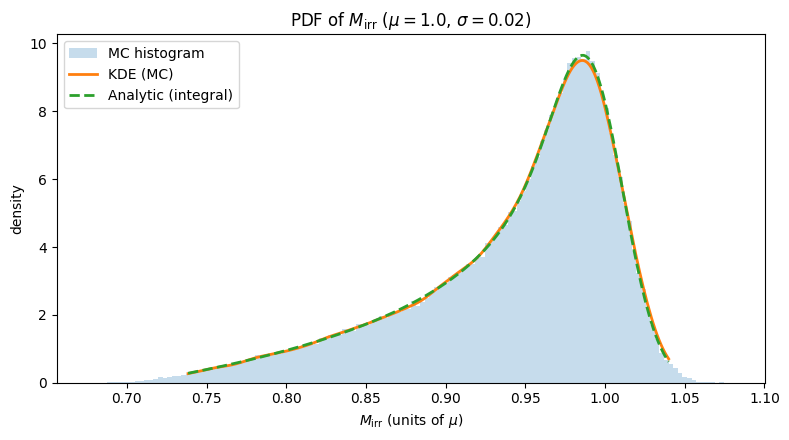

In [62]:
# analytic pdf of Mirr using the hint formula
def p_Mirr(z, mu, sigma): # pdf of Mirr at z, given M ~ N(mu, sigma)
    lo, hi = 1/np.sqrt(2), 1.0

    # integrand for fixed z
    def integrand(f): # integrand over f
        return np.exp(-0.5*((z/f - mu)/sigma)**2) * (2*f**2 - 1) / (f*np.sqrt(1 - f**2))

    val, err = quad(integrand, lo, hi, limit=200) # integrate over f
    return np.sqrt(2/np.pi) * (1.0/sigma) * val 

# Vectorize for arrays (calls quad many times; OK for moderate grid sizes)
p_Mirr_vec = np.vectorize(p_Mirr, excluded=["mu", "sigma"])

# Choose parameters and generate MC samples for comparison
mu = 1.0
sigma = 0.02
N = 200_000

rng = np.random.default_rng(123) # reproducible
M = rng.normal(mu, sigma, size=N)  # untruncated normal to match analytic assumption
chi = rng.uniform(0, 1, size=N)
f = np.sqrt((1 + np.sqrt(1 - chi**2))/2) # compute f from chi
Mirr = M * f # compute Mirr

# KDE from samples
kde = gaussian_kde(Mirr) # default bandwidth (Scott's rule)

# Grid for plotting
z_grid = np.linspace(np.percentile(Mirr, 0.5), np.percentile(Mirr, 99.5), 250)

pdf_kde = kde(z_grid) #KDE estimate from samples
pdf_ana = p_Mirr_vec(z_grid, mu=mu, sigma=sigma) # analytic integral estimate

plt.figure(figsize=(8,4.5))
plt.hist(Mirr, bins=140, density=True, alpha=0.25, label="MC histogram")
plt.plot(z_grid, pdf_kde, lw=2, label="KDE (MC)")
plt.plot(z_grid, pdf_ana, lw=2, linestyle="--", label="Analytic (integral)")
plt.xlabel(r"$M_{\rm irr}$ (units of $\mu$)")
plt.ylabel("density")
plt.title(rf"PDF of $M_{{\rm irr}}$ ($\mu={mu}$, $\sigma={sigma}$)")
plt.legend()
plt.tight_layout()
plt.show()
